In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
import scipy
import matplotlib
from matplotlib import rcParams
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # to show output from all the lines in a cells
pd.set_option('display.max_column',None) # display all the columns in pandas
pd.options.display.max_rows = 100
rcParams['pdf.fonttype'] = 42
sc.settings.figdir = './figures/figure4_S6/'
sc.settings.set_figure_params(dpi = 150, color_map = 'RdPu', dpi_save = 600, vector_friendly = True, format = 'pdf')

In [2]:
cd F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\

F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline


G:\Miniconda3\envs\omicverse\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
data_dir = '/PROJECTS/PROJECT_HUMAN_FETAL_COCHLEAE/WORKPLACE/R/sc_pipeline/'
meta = pd.read_csv(data_dir+'metadata.csv',index_col=0)
meta

         sample_id           donor  gw  gender 10xKit sequencing   dataset  \
sample                                                                       
9.5gw          gw9  not_provided_1   9  female    SC3  snRNA-seq    public   
11.2gw        gw11  not_provided_2  11    male    SC3  snRNA-seq    public   
14+3gw        gw14       F20240701  14    male    SC3  snRNA-seq  in-house   
15gw          gw15  not_provided_3  15  female    SC3  scRNA-seq    public   
16+4gw        gw16       F20241018  16    male    SC3  snRNA-seq  in-house   
17+2gw      gw17_1       F20220807  17    male    SC3  snRNA-seq  in-house   
17+3gw      gw17_2       F20240928  17  female    SC3  snRNA-seq  in-house   
17gw        gw17_3  not_provided_4  17    male    SC3  scRNA-seq    public   
18+3gw        gw18       F20220806  18    male    SC3  snRNA-seq  in-house   
20gw          gw20     F20240928-2  20  female    SC3  snRNA-seq  in-house   
22+2gw_1    gw22_1       F20241021  22    male    SC3  snRNA-seq

### FIGURE S6a/b

In [4]:
mouse_adult=sc.read('Mm_sgn_python.h5ad')
mouse_adult

AnnData object with n_obs × n_vars = 792 × 14530
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.8', 'seurat_clusters', 'integrated_snn_res.1', 'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'integrated_snn_res.0.5', 'integrated_snn_res.0.6', 'integrated_snn_res.0.7', 'integrated_snn_res.0.9', 'subclass_label', 'cluster_label', 'seurat_clusters.new', 'celltype_species'
    var: 'name'
    obsm: 'X_pca', 'X_umap'

In [5]:
mouse_adult.layers['counts']=mouse_adult.X.copy()
sc.pp.normalize_total(mouse_adult)
sc.pp.log1p(mouse_adult)
mouse_adult.layers["logcounts"]=mouse_adult.X.copy()
mouse_adult.layers["scaled"]=sc.pp.scale(mouse_adult.X,max_value=5,copy=True)
mouse_adult

G:\Miniconda3\envs\omicverse\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 792 × 14530
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.8', 'seurat_clusters', 'integrated_snn_res.1', 'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'integrated_snn_res.0.5', 'integrated_snn_res.0.6', 'integrated_snn_res.0.7', 'integrated_snn_res.0.9', 'subclass_label', 'cluster_label', 'seurat_clusters.new', 'celltype_species'
    var: 'name'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'logcounts', 'scaled'

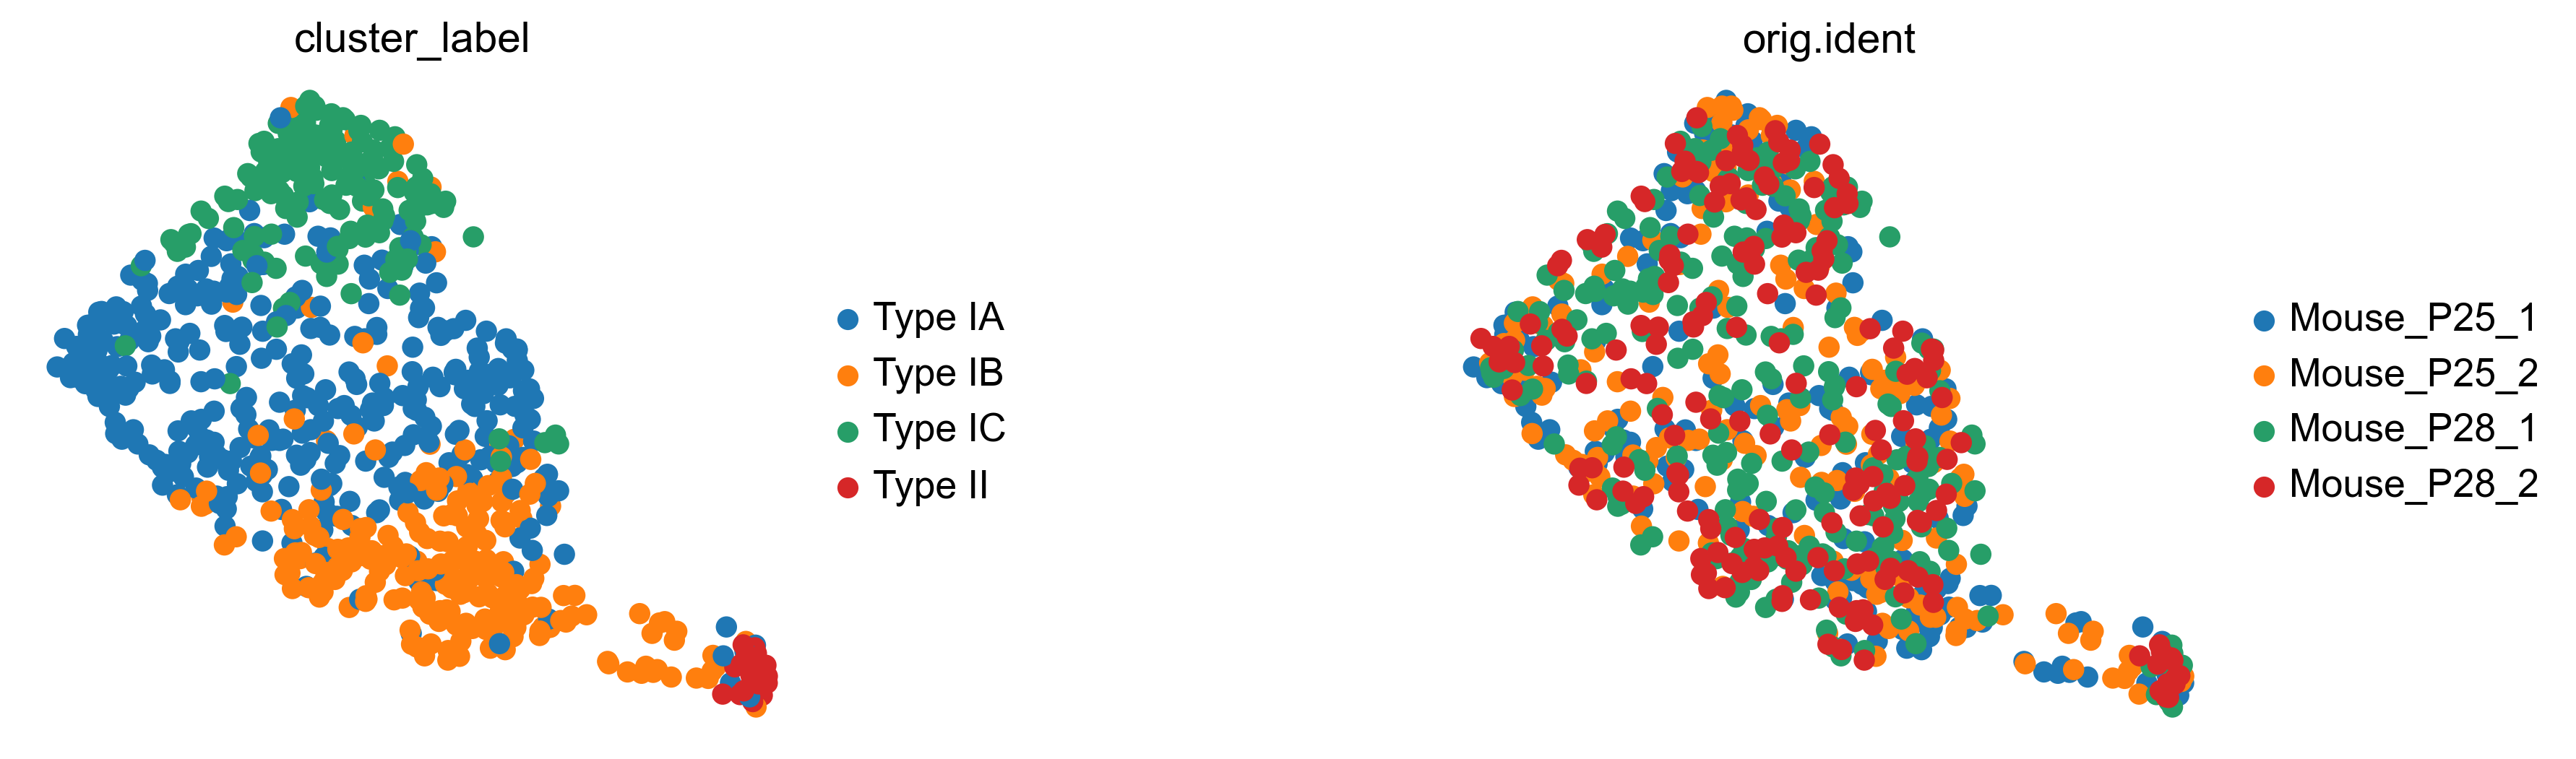

In [6]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(mouse_adult, color=['cluster_label','orig.ident'],size=200,
           wspace=0.65,ncols=2,color_map = "RdPu",
           save='_mouse_adult_sgn.pdf'
          )

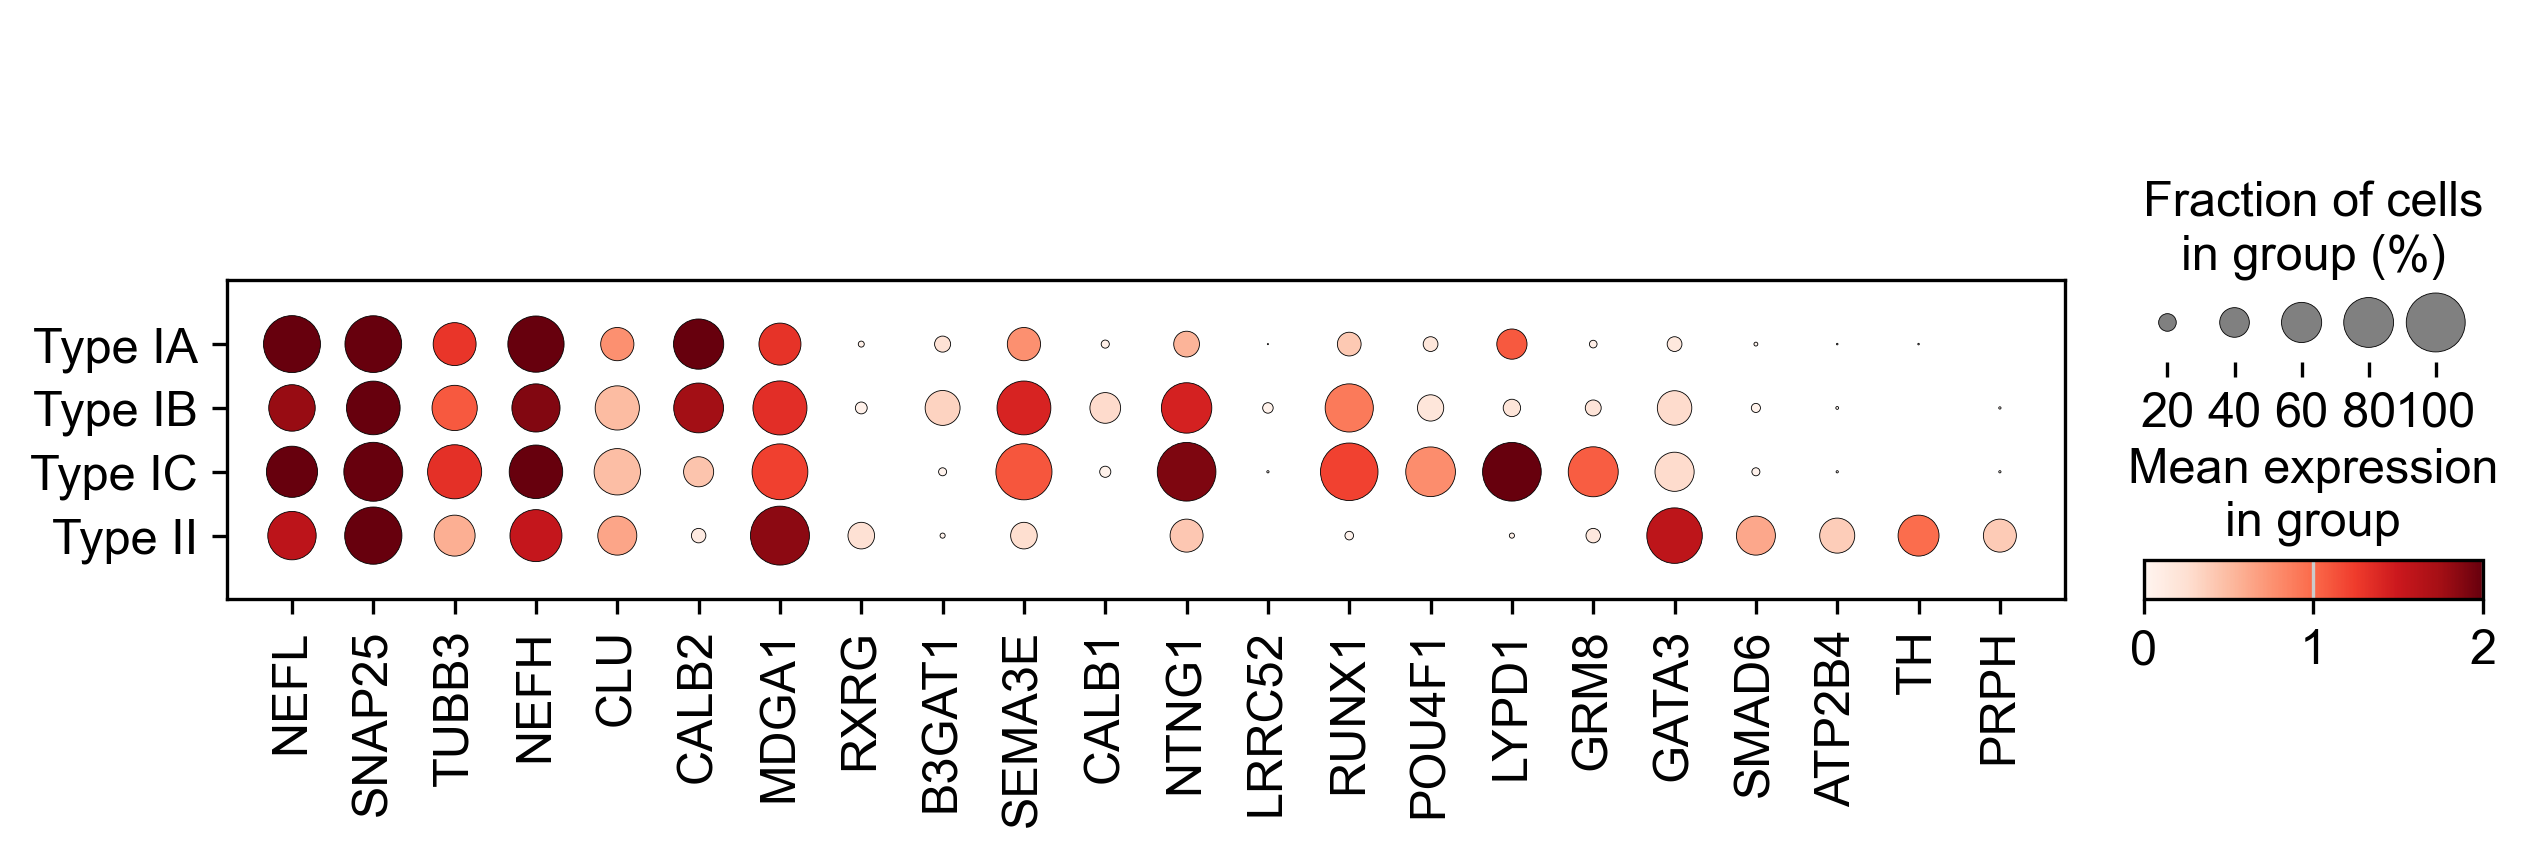

In [7]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.dotplot(mouse_adult, var_names=["NEFL","SNAP25","TUBB3","NEFH","CLU",  #TYPE I SGN 
                   "CALB2","MDGA1","RXRG","B3GAT1",  #IA
                   "SEMA3E", "CALB1","NTNG1","LRRC52",    #IB
                   "RUNX1", "POU4F1","LYPD1","GRM8",            #IC
                   "GATA3","SMAD6","ATP2B4","TH","PRPH" #TYPE II
                                                     ],
              groupby='cluster_label', 
             vmax=2,
             
              save="_mouse_adult_sgn.pdf",
             )#standard_scale='var',swap_axes=True,

### FIGURE S6c/d
#### please note that this section was re-run to repeat the pipeline, so the results will be changed.

In [8]:
adata_positive_final_sgn_hm=sc.read('human_sgn_harmony_integration_final_sgn_final_CELLTYPE_ANNOTATED.h5ad')

In [9]:
adata_final_sgn=sc.read('human_final_sgn_rawcounts.h5ad')

In [10]:
adata_positive_final_sgn_hm_v2=adata_final_sgn[adata_positive_final_sgn_hm.obs.index]
adata_positive_final_sgn_hm_v2

View of AnnData object with n_obs × n_vars = 133 × 23412
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'logcounts'

In [11]:
adata=adata_positive_final_sgn_hm.copy()
adata_positive_final_sgn_hm_v2.obsm['X_pca']=adata.obsm['X_pca']
adata_positive_final_sgn_hm_v2.obsm['X_harmony']=adata.obsm['X_harmony']
adata_positive_final_sgn_hm_v2.obsm['X_umap']=adata.obsm['X_umap']
adata_positive_final_sgn_hm_v2.uns['log1p']=adata.uns['log1p']
adata_positive_final_sgn_hm_v2.uns['hvg']=adata.uns['hvg']
adata_positive_final_sgn_hm_v2.uns['pca']=adata.uns['pca']
adata_positive_final_sgn_hm_v2.uns['neighbors']=adata.uns['neighbors']
adata_positive_final_sgn_hm_v2.uns['umap']=adata.uns['umap']
adata_positive_final_sgn_hm_v2.uns['batch_colors']=adata.uns['batch_colors']
adata_positive_final_sgn_hm_v2.uns['cell_type_final_colors']=adata.uns['cell_type_final_colors']
adata_positive_final_sgn_hm_v2.uns['leiden_0.4']=adata.uns['leiden_0.4']
adata_positive_final_sgn_hm_v2.var['n_cells']=adata.var['n_cells']
adata_positive_final_sgn_hm_v2.var['highly_variable']=adata.var['highly_variable']
adata_positive_final_sgn_hm_v2.var['means']=adata.var['means']
adata_positive_final_sgn_hm_v2.var['dispersions']=adata.var['dispersions']
adata_positive_final_sgn_hm_v2.obs['CellID']=adata.obs['CellID']
adata_positive_final_sgn_hm_v2.obs['batch']=adata.obs['batch']
adata_positive_final_sgn_hm_v2.obs['n_genes_by_counts']=adata.obs['n_genes_by_counts']
adata_positive_final_sgn_hm_v2.obs['cell_type']=adata.obs['cell_type']
adata_positive_final_sgn_hm_v2.obs['total_counts']=adata.obs['total_counts']
adata_positive_final_sgn_hm_v2.obs['total_counts_mt']=adata.obs['total_counts_mt']
adata_positive_final_sgn_hm_v2.obs['pct_counts_mt']=adata.obs['pct_counts_mt']
adata_positive_final_sgn_hm_v2.obs['doublet_score']=adata.obs['doublet_score']
adata_positive_final_sgn_hm_v2.obs['cell_type_final']=adata.obs['cell_type_final']

adata_positive_final_sgn_hm_v2.obsp['connectivities']=adata.obsp['connectivities']
adata_positive_final_sgn_hm_v2.obsp['distances']=adata.obsp['distances']

C:\Users\Dell\AppData\Local\Temp\ipykernel_14884\3030118982.py:2: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata_positive_final_sgn_hm_v2.obsm['X_pca']=adata.obsm['X_pca']


#### scVI-based Label-transfer

In [40]:
import os
import tempfile
import scanpy as sc
import scvi
import seaborn as sns
import torch

In [42]:
pip list

Package                   Version
------------------------- ------------
absl-py                   2.5.0
adjustText                0.8
aiofiles                  25.1.0
aiohappyeyeballs          2.7.1
aiohttp                   3.14.2
aiosignal                 1.4.0
anndata                   0.11.4
annotated-doc             0.0.4
annotated-types           0.7.0
anyio                     4.14.2
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
array-api-compat          1.15.0
arrow                     1.4.0
asciitree                 0.3.3
asttokens                 3.0.2
astunparse                1.6.3
async-lru                 2.3.0
async-timeout             5.0.1
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.15.0
biopython                 1.88
bleach                    6.4.0
Bottleneck                1.4.2
celltypist                1.7.1
certifi                   2026.7.22
cffi                      2.1.0
charset-normalizer  

In [43]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scvi-tools version: 1.3.3


In [44]:
# Load dataset we want to transfer label to
adata_to = adata_positive_final_sgn_hm_v2
print("adata_to dims: {}".format(adata_to.shape))
adata_from=mouse_adult
print("adata_from dims: {}".format(adata_from.shape))

adata_to dims: (133, 23412)
adata_from dims: (792, 14530)


In [45]:
adata_to.obs['species']='human'
adata_from.obs['species']='mouse'

In [46]:
adata_to.obs['celltype']=adata_to.obs['cell_type_final']
adata_from.obs['celltype']=adata_from.obs['cluster_label']

In [47]:
import anndata

In [48]:
adata = anndata.concat([adata_to, adata_from])
adata

AnnData object with n_obs × n_vars = 925 × 14337
    obs: 'species', 'celltype'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'logcounts'

In [49]:
adata.X = adata.layers['counts'].copy()

In [50]:
#adata = anndata.concat([adata_to, adata_from])
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata  # keep full dimension safe
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
    n_top_genes=10000, # change to respective hvgs
    layer="counts",
    batch_key="species",
    subset=True,
)

In [51]:
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="species")

In [52]:
scvi_model = scvi.model.SCVI(adata, n_layers=2, n_latent=30)

In [53]:
scvi_model.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pytorch\loops\fit_loop.py:321: The number of training batches (7) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [ ]:
SCVI_LATENT_KEY = "X_scVI"
adata.obsm[SCVI_LATENT_KEY] = scvi_model.get_latent_representation()
from scvi.model.utils import mde
SCVI_MDE_KEY = "X_scVI_mde"
adata.obsm[SCVI_MDE_KEY] = mde(adata.obsm[SCVI_LATENT_KEY])
sc.pl.embedding(
    adata,
    basis=SCVI_MDE_KEY,
    color=["species"],
    frameon=False,
    ncols=1,
)
sc.pl.embedding(adata, color="celltype", frameon=False, basis=SCVI_MDE_KEY)


In [ ]:
SCANVI_CELLTYPE_KEY = "celltype_scanvi"

adata.obs[SCANVI_CELLTYPE_KEY] = "Unknown"
ss2_mask = adata.obs["species"] == "mouse"
adata.obs[SCANVI_CELLTYPE_KEY][ss2_mask] = adata.obs.celltype[ss2_mask].values

In [ ]:
np.unique(adata.obs[SCANVI_CELLTYPE_KEY], return_counts=True)

In [ ]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    scvi_model,
    adata=adata,
    unlabeled_category="Unknown",
    labels_key=SCANVI_CELLTYPE_KEY,
)

In [ ]:
scanvi_model.train(max_epochs=20, n_samples_per_label=100)

In [ ]:
SCANVI_LATENT_KEY = "X_scANVI"
SCANVI_PREDICTION_KEY = "C_scANVI"

adata.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation(adata)
adata.obs[SCANVI_PREDICTION_KEY] = scanvi_model.predict(adata)

In [ ]:
SCANVI_MDE_KEY = "X_mde_scanvi"
adata.obsm[SCANVI_MDE_KEY] = mde(adata.obsm[SCANVI_LATENT_KEY])

In [ ]:
adata2=adata.copy()

In [ ]:
sc.pp.neighbors(adata2,n_neighbors=30,use_rep="X_mde_scanvi")
sc.tl.umap(adata2,min_dist=0.6)

In [ ]:
# in order to make colors matchup
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=300,dpi_save=600)
adata2.obs.C_scANVI = pd.Categorical(
    adata2.obs.C_scANVI.values, categories=adata2.obs.celltype.cat.categories
)
sc.pl.embedding(
    adata2,
    basis=SCANVI_MDE_KEY,
    color=["celltype", SCANVI_PREDICTION_KEY,'species'],
    ncols=3,
    palette=adata.uns["celltype_colors"],wspace=0.3, legend_fontsize=7,size=50,
    frameon=True, save="scANVI_label_transfer_human-mouse_sgn.pdf"
)

In [ ]:
dataframe = adata.obs.groupby(["celltype", SCANVI_PREDICTION_KEY]).size().unstack(fill_value=0)

In [ ]:
conf_mat = dataframe / dataframe.sum(axis=1).values[:, np.newaxis]

In [ ]:
plt.figure(figsize=(8, 8))
_ = plt.pcolor(conf_mat,cmap='RdPu')
_ = plt.xticks(np.arange(0.5, len(dataframe.columns), 1), dataframe.columns, rotation=90)
_ = plt.yticks(np.arange(0.5, len(dataframe.index), 1), dataframe.index)
plt.xlabel("Predicted")
plt.ylabel("Observed")
plt.savefig('CORRPLOT_HUMAN-MOUSE_SGN_SCANVI_10000HVGS.pdf')

#### Reference mapping with scvi-tools

In [56]:
#Reference mapping with scvi-tools
adata_query=adata_to.copy()
adata_query
adata_ref=adata_from.copy()
adata_ref

AnnData object with n_obs × n_vars = 133 × 23412
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'doublet_score', 'cell_type_final', 'species', 'celltype'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'batch_colors', 'cell_type_final_colors', 'leiden_0.4'
    obsm: 'X_pca', 'X_umap', 'X_harmony'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

AnnData object with n_obs × n_vars = 792 × 14530
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.8', 'seurat_clusters', 'integrated_snn_res.1', 'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'integrated_snn_res.0.5', 'integrated_snn_res.0.6', 'integrated_snn_res.0.7', 'integrated_snn_res.0.9', 'subclass_label', 'cluster_label', 'seurat_clusters.new', 'celltype_species', 'species', 'celltype'
    var: 'name'
    uns: 'log1p', 'cluster_label_colors', 'orig.ident_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'logcounts', 'scaled'

In [57]:
adata = anndata.concat([adata_query, adata_ref])
adata

AnnData object with n_obs × n_vars = 925 × 14337
    obs: 'species', 'celltype'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'logcounts'

In [58]:
#We run highly variable gene selection on the reference data and use these same genes for the query data.
sc.pp.highly_variable_genes(adata_ref, n_top_genes=2000, batch_key="orig.ident", subset=True)
adata_ref

AnnData object with n_obs × n_vars = 792 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.8', 'seurat_clusters', 'integrated_snn_res.1', 'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'integrated_snn_res.0.5', 'integrated_snn_res.0.6', 'integrated_snn_res.0.7', 'integrated_snn_res.0.9', 'subclass_label', 'cluster_label', 'seurat_clusters.new', 'celltype_species', 'species', 'celltype'
    var: 'name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'cluster_label_colors', 'orig.ident_colors', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'logcounts', 'scaled'

In [59]:
# Find genes present in both datasets
common_genes = adata_query.var_names.intersection(adata_ref.var_names)

# Subset both datasets to only these common genes
adata_query = adata_query[:, common_genes].copy()
adata_ref = adata_ref[:, common_genes].copy()

In [60]:
#We train the reference using the standard SCVI workflow, except we add a few non-default parameters that were identified to work well with scArches. 
#It is essential to encode covariates here as this allows scArches to map new batches in the encoder to the existing data and 
#thereby provides batch integration.
scvi.model.SCVI.setup_anndata(adata_ref, batch_key="orig.ident", layer="counts")

G:\Miniconda3\envs\omicverse\lib\site-packages\scvi\data\fields\_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [61]:
scvi_ref = scvi.model.SCVI(
    adata_ref,
    use_layer_norm="both",
    use_batch_norm="none",
    encode_covariates=True,
    dropout_rate=0.2,
    n_layers=2,
)
scvi_ref.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pytorch\loops\fit_loop.py:321: The number of training batches (6) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [62]:
SCVI_LATENT_KEY = "X_scVI"
adata_ref.obsm[SCVI_LATENT_KEY] = scvi_ref.get_latent_representation()
sc.pp.neighbors(adata_ref, use_rep=SCVI_LATENT_KEY)
sc.tl.leiden(adata_ref)
sc.tl.umap(adata_ref)

C:\Users\Dell\AppData\Local\Temp\ipykernel_14884\3947138504.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_ref)


In [ ]:
sc.pl.umap(
    adata_ref,
    color=["celltype", "orig.ident"],
    frameon=False,
    ncols=2,
)

In [63]:
import os

# Define your custom save path
save_path = r"F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\human_sgn_ref_mapping"

# Create directory if it doesn't exist
os.makedirs(save_path, exist_ok=True)

# Define full model path and save
scvi_ref_path = os.path.join(save_path, "human_sgn_scvi_ref")
scvi_ref.save(scvi_ref_path, overwrite=True)

In [64]:
#First we validate that our query data is ready to be loaded into the reference model.
#Here we run prepare_query_anndata, which reorders the genes and pads any missing genes with 0s. 
#This should generally be run before reference mapping with scArches to ensure data correctness. 
#In the case of this tutorial, nothing happens as the query data is already “correct”.
# both are valid
scvi.model.SCVI.prepare_query_anndata(adata_query, scvi_ref_path)
scvi.model.SCVI.prepare_query_anndata(adata_query, scvi_ref)

INFO     File                                                                                                      
         F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\human_sgn_ref_mapping\human_sgn_scvi_ref\
         model.pt already downloaded                                                                               
INFO     Found 100.0% reference vars in query data.                                                                
INFO     Found 100.0% reference vars in query data.                                                                


In [65]:
adata_query.obs['orig.ident'] = adata_query.obs['batch']

In [66]:
#Now we create the new query model instance
# both are valid
scvi_query = scvi.model.SCVI.load_query_data(
    adata_query,
    scvi_ref_path,
)
scvi_query = scvi.model.SCVI.load_query_data(
    adata_query,
    scvi_ref,
)

INFO     File                                                                                                      
         F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\human_sgn_ref_mapping\human_sgn_scvi_ref\
         model.pt already downloaded                                                                               


In [67]:
# This is a typical SCVI object, and after training, can be used in any defined way.
#For training the query data, we recommend using a weight_decay of 0.0. 
#This ensures the latent representation of the reference cells will remain exactly the same if passing them through this new query model.
scvi_query.train(max_epochs=200, plan_kwargs={"weight_decay": 0.0})
adata_query.obsm[SCVI_LATENT_KEY] = scvi_query.get_latent_representation()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pytorch\loops\fit_loop.py:321: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pyt

Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


In [68]:
sc.pp.neighbors(adata_query, use_rep=SCVI_LATENT_KEY)
sc.tl.leiden(adata_query)
sc.tl.umap(adata_query)

In [ ]:
sc.pl.umap(
    adata_query,
    color=["orig.ident", "celltype"],
    frameon=False,
    ncols=2,
)

In [69]:
adata_full = anndata.concat([adata_query, adata_ref])
adata_full

AnnData object with n_obs × n_vars = 925 × 1971
    obs: 'leiden', 'species', 'celltype', 'orig.ident', '_scvi_batch', '_scvi_labels'
    obsm: 'X_pca', 'X_umap', 'X_scVI'
    layers: 'counts', 'logcounts'

In [70]:
adata_full.obsm[SCVI_LATENT_KEY] = scvi_query.get_latent_representation(adata_full)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [71]:
sc.pp.neighbors(adata_full, use_rep=SCVI_LATENT_KEY)
sc.tl.leiden(adata_full)
sc.tl.umap(adata_full)

In [ ]:
sc.pl.umap(
    adata_full,
    color=["orig.ident", "celltype",'species'],
    frameon=False,wspace=0.5,
    ncols=3,
)

##### The advantage of SCANVI is that we’ll be able to predict the cell type labels of the query dataset. In the case of SCVI,
##### a separate classifier (e.g., nearest-neighbor, random forest, etc.) would have to be trained on the reference latent space.
##### SCANVI tends to perform better in situations where it has been initialized using a pre-trained SCVI model. In this case,
##### we will use vae_ref that we have already trained above.

In [72]:
from scvi.model import SCVI, SCANVI

In [73]:
arches_params = {
    "n_layers": 2,               # Number of hidden layers
    "n_hidden": 128,             # Number of nodes per hidden layer
    "n_latent": 30,              # Dimensionality of latent space
    "dropout_rate": 0.1,         # Dropout rate
    "gene_likelihood": "nb",     # "nb" (negative binomial) or "zinb" (zero-inflated negative binomial)
    "use_layer_norm": "both",    # Normalization ("none", "encoder", "decoder", or "both")
    "use_batch_norm": "none"     # Batch normalization
}

In [74]:
scvi_model = SCVI(adata_ref, **arches_params)
scvi_model.train()
scanvi_model = SCANVI.from_scvi_model(scvi_model, unlabeled_category="Unknown",labels_key='celltype')
scanvi_model.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pytorch\loops\fit_loop.py:321: The number of training batches (6) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


INFO     Training for 10 epochs.                                                                                   


G:\Miniconda3\envs\omicverse\lib\site-packages\scvi\data\fields\_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\

Training:   0%|          | 0/10 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


In [75]:
SCANVI_LABELS_KEY = "labels_scanvi"

adata_ref.obs[SCANVI_LABELS_KEY] = adata_ref.obs["celltype"].values

In [76]:
# unlabeled category does not exist in adata.obs[labels_key]
# so all cells are treated as labeled
scanvi_ref = scvi.model.SCANVI.from_scvi_model(
    scvi_ref,
    unlabeled_category="Unknown",
    labels_key=SCANVI_LABELS_KEY,
)

G:\Miniconda3\envs\omicverse\lib\site-packages\scvi\data\fields\_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [77]:
scanvi_ref.train(max_epochs=20, n_samples_per_label=100)

INFO     Training for 20 epochs.                                                                                   


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pytorch\loops\fit_loop.py:321: The number of training batches (6) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training:   0%|          | 0/20 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


In [78]:
SCANVI_LATENT_KEY = "X_scANVI"

adata_ref.obsm[SCANVI_LATENT_KEY] = scanvi_ref.get_latent_representation()
sc.pp.neighbors(adata_ref, use_rep=SCANVI_LATENT_KEY)
sc.tl.leiden(adata_ref)
sc.tl.umap(adata_ref)

In [ ]:
sc.pl.umap(
    adata_ref,
    color=["orig.ident", "celltype"],
    frameon=False,
    ncols=2,
)

In [79]:
scanvi_ref_path = os.path.join(save_path, "human_sgn_scanvi_ref")
scanvi_ref.save(scanvi_ref_path, overwrite=True)

In [80]:
# again a no-op in this tutorial, but good practice to use
scvi.model.SCANVI.prepare_query_anndata(adata_query, scanvi_ref_path)

INFO     File                                                                                                      
         F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\human_sgn_ref_mapping\human_sgn_scanvi_re
         f\model.pt already downloaded                                                                             
INFO     Found 100.0% reference vars in query data.                                                                


###### Notice that adata_query.obs["labels_scanvi"] does not exist. The load_query_data method detects this and fills it in adata_query with the unlabeled category (here "Unknown").

In [81]:
scanvi_query = scvi.model.SCANVI.load_query_data(adata_query, scanvi_ref_path)

INFO     File                                                                                                      
         F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\human_sgn_ref_mapping\human_sgn_scanvi_re
         f\model.pt already downloaded                                                                             


G:\Miniconda3\envs\omicverse\lib\site-packages\scvi\data\_manager.py:220: UserWarning: Missing labels key labels_scanvi. Filling in with unlabeled category Unknown.
  if source_registry is not None:


In [82]:
scanvi_query.train(
    max_epochs=100,
    plan_kwargs={"weight_decay": 0.0},
    check_val_every_n_epoch=10,
)

INFO     Training for 100 epochs.                                                                                  


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pytorch\loops\fit_loop.py:321: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pyt

Training:   0%|          | 0/100 [00:00<?, ?it/s]

G:\Miniconda3\envs\omicverse\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=47` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=100` reached.


In [83]:
SCANVI_PREDICTIONS_KEY = "predictions_scanvi"

adata_query.obsm[SCANVI_LATENT_KEY] = scanvi_query.get_latent_representation()
adata_query.obs[SCANVI_PREDICTIONS_KEY] = scanvi_query.predict()

C:\Users\Dell\AppData\Local\Temp\ipykernel_14884\1238423782.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = adata_query.obs.groupby(["celltype", SCANVI_PREDICTIONS_KEY]).size().unstack(fill_value=0)


<Figure size 450x450 with 0 Axes>

Text(0.5, 0, 'Predicted')

Text(0, 0.5, 'Observed')

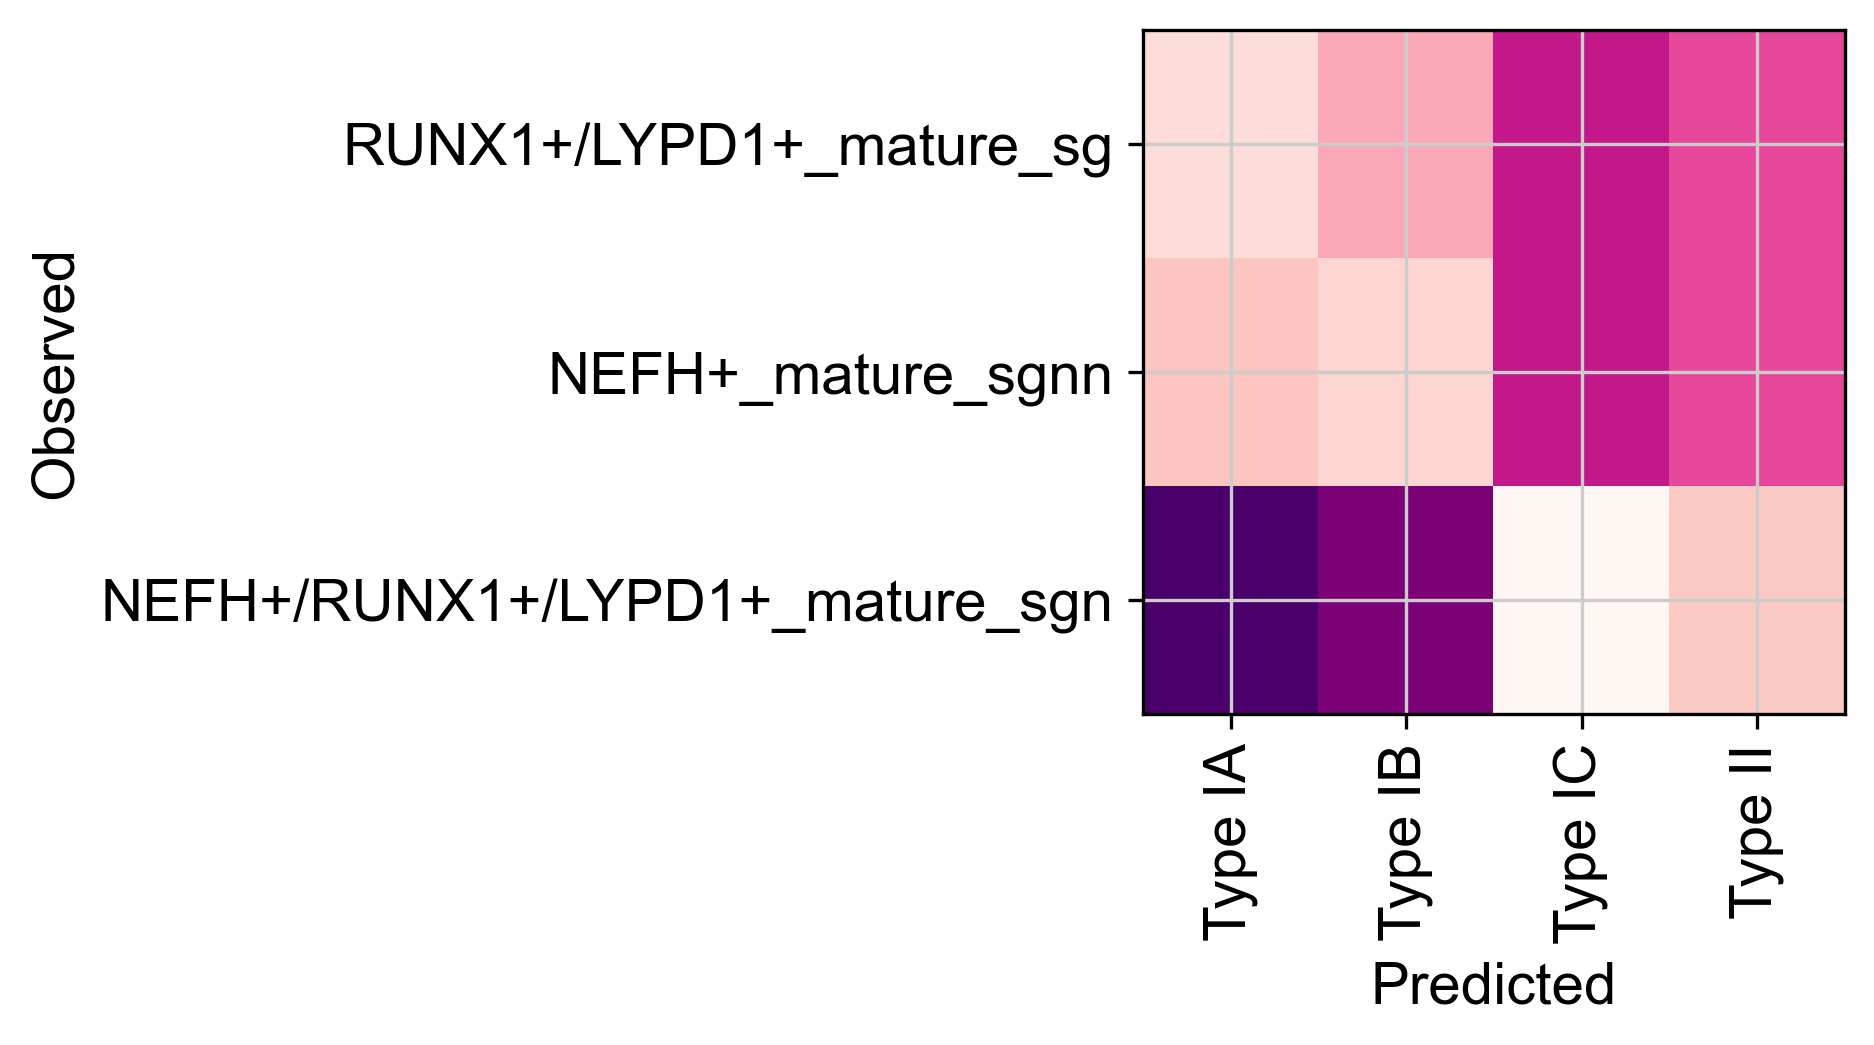

In [84]:
df = adata_query.obs.groupby(["celltype", SCANVI_PREDICTIONS_KEY]).size().unstack(fill_value=0)
norm_df = df / df.sum(axis=0)

plt.figure(figsize=(3, 3))
_ = plt.pcolor(norm_df,cmap='RdPu')
_ = plt.xticks(np.arange(0.5, len(df.columns), 1), df.columns, rotation=90)
_ = plt.yticks(np.arange(0.5, len(df.index), 1), df.index)
plt.xlabel("Predicted")
plt.ylabel("Observed")

### FIGURE S6e/f

##### SVM MACHINE LEARNING

In [85]:
import os 
import sys
import datetime
import numpy
import pandas
import scanpy 
import anndata
import scipy 
import matplotlib.pyplot
import functools
import random
import itertools
import warnings
import argparse
import seaborn

In [86]:
# Required libraries regardless of the model you choose

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [87]:
# Library for Logistic Regression
from sklearn.linear_model import LogisticRegression

# Library for Random Forest 
from sklearn.ensemble import RandomForestClassifier

# Library for Support Vector Machine 
from sklearn.svm import SVC

#Suppress lots of memory warning
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
from os.path import expanduser as eu
from os import path

scanpy.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

from itertools import chain

In [88]:
def preprocessing_training(adata, hvgs):
    # Per cell normalization
    sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
    # Log transformation 
    sc.pp.log1p(adata)
    # Filter HVGs --> Select top N highly variable genes that will serve as features to the machine learning models  
    sc.pp.highly_variable_genes(adata, n_top_genes = hvgs)
    highly_variable_genes = adata.var["highly_variable"]
    adata = adata[:, highly_variable_genes]
    # Scale
    sc.pp.scale(adata, max_value=10)
    return adata

def preprocessing_testing(adata, hvgs): 
    # Per cell normalization
    sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
    # Log transformation 
    sc.pp.log1p(adata)
    # Use the HVGs that were selected for the training set 
    adata = adata[:, hvgs]
    # Scale
    sc.pp.scale(adata, max_value=10)
    return adata

In [89]:
adata = anndata.concat([adata_to, adata_from])
adata

AnnData object with n_obs × n_vars = 925 × 14337
    obs: 'species', 'celltype'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'logcounts'

In [90]:
adata_human2= adata[adata.obs['species'].isin(['human']), :]
adata_human2
adata_mouse2= adata[adata.obs['species'].isin(['mouse']), :]
adata_mouse2

View of AnnData object with n_obs × n_vars = 133 × 14337
    obs: 'species', 'celltype'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'logcounts'

View of AnnData object with n_obs × n_vars = 792 × 14337
    obs: 'species', 'celltype'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'logcounts'

In [91]:
X_df = pd.DataFrame(adata_mouse2.X.toarray(), index = adata_mouse2.obs_names, columns = adata_mouse2.var_names) 
# Fetching the count matrix to use as input to the model 
print(type(X_df), X_df.shape)

<class 'pandas.core.frame.DataFrame'> (792, 14337)


In [92]:
# Labels we want to predict 
y = list(adata_mouse2.obs['celltype'].astype('str'))
print('List of unique labels we wish to transfer: {}'.format(numpy.unique(y)))

List of unique labels we wish to transfer: ['Type IA' 'Type IB' 'Type IC' 'Type II']


In [94]:
# Split the training dataset into train and test sets 
X_train, X_test, y_train, y_test = train_test_split(
        X_df,
        y,
        test_size=0.3, # This can be changed, though it makes sense to use 25-30% of the data for test
        random_state=1234,
    )

X_train_indices = X_train.index.to_list()
X_test_indices = X_test.index.to_list()
X_train = preprocessing_training(adata_mouse2[X_train_indices, :], 2500)#n_hvgs 1000

hvgs_X_train = X_train.var_names.to_list()
X_test = preprocessing_testing(adata_mouse2[X_test_indices, :], hvgs_X_train)

X_train = X_train.X
X_test = X_test.X

normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added
    'n_counts', counts per cell before normalization (adata.obs)
extracting highly variable genes


C:\Users\Dell\AppData\Local\Temp\ipykernel_14884\3719484138.py:3: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
G:\Miniconda3\envs\omicverse\lib\site-packages\scanpy\preprocessing\_simple.py:587: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_n_counts] = counts_per_cell
G:\Miniconda3\envs\omicverse\lib\site-packages\scanpy\preprocessing\_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added
    'n_counts', counts per cell before normalization (adata.obs)


G:\Miniconda3\envs\omicverse\lib\site-packages\scanpy\preprocessing\_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
G:\Miniconda3\envs\omicverse\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\Dell\AppData\Local\Temp\ipykernel_14884\3719484138.py:16: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
G:\Miniconda3\envs\omicverse\lib\site-packages\scanpy\preprocessing\_simple.py:587: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_n_counts] = counts_per_cell
G:\Miniconda3\envs\omicverse\lib\site-packages\scanpy\preprocessing\_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(
G:\Miniconda3\envs\omicverse\lib\site-packages\scanpy\preprocessing\_scale.py:309: UserWarning: Received a v

In [95]:
# Train supervised learning models #
# Compute smoothing class weights 
def class_weight(labels_dict,mu=0.15):
    total = numpy.sum(list(labels_dict.values()))
    keys = labels_dict.keys()
    weight = {}
    print(total)

    for i in keys:
        score = numpy.log(mu*total/float(labels_dict[i]))
        weight[i] = score if score > 1 else 1
    return weight

labels_dict = {}
for i in y_train:
    labels_dict[i] = labels_dict.get(i, 0) + 1

print(labels_dict)
weights = class_weight(labels_dict)

{'Type IB': 161, 'Type IA': 266, 'Type IC': 110, 'Type II': 17}
554


In [96]:
#Training a Support Vector Machine multiclass classifier
svm = SVC(kernel = "rbf", probability = True, class_weight = weights)

In [97]:
pca = PCA()
pca

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [98]:
pipe = Pipeline(steps=[('pca', pca), ('SVC', svm)])
print('Starting hyperparameter tuning with exhaustive grid search')

Starting hyperparameter tuning with exhaustive grid search


In [99]:
# Choose a grid of hyperparameters values (these are arbitrary but reasonable as I took reference values from the documentation)
params_svm = {'SVC__C':[0.1, 1, 10, 100], 'SVC__gamma':[0.001, 0.01, 0.1], 'pca__n_components': [0.7, 0.8, 0.9]}

In [100]:
# Use grid search cross validation to span the hyperparameter space and choose the best 
grid = GridSearchCV(pipe, param_grid = params_svm, cv=5, verbose =1, n_jobs = -1)
grid

,estimator,Pipeline(step...ility=True))])
,param_grid,"{'SVC__C': [0.1, 1, ...], 'SVC__gamma': [0.001, 0.01, ...], 'pca__n_components': [0.7, 0.8, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,None


In [101]:
# Fit the model to the training set of the training data
grid.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,estimator,Pipeline(step...ility=True))])
,param_grid,"{'SVC__C': [0.1, 1, ...], 'SVC__gamma': [0.001, 0.01, ...], 'pca__n_components': [0.7, 0.8, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,0.8


In [102]:
# Evaluate supervised learning models #
predicted_labels = grid.best_estimator_.predict(X_test) 
report = classification_report(y_test, predicted_labels)
print("Accuracy:", accuracy_score(y_test, predicted_labels))
print(report)

Accuracy: 0.8991596638655462
              precision    recall  f1-score   support

     Type IA       0.99      0.90      0.94       114
     Type IB       0.78      0.91      0.84        68
     Type IC       0.88      0.89      0.88        47
     Type II       1.00      0.78      0.88         9

    accuracy                           0.90       238
   macro avg       0.91      0.87      0.89       238
weighted avg       0.91      0.90      0.90       238



([<matplotlib.axis.XTick at 0x2166012e050>,
 [Text(0, 0, '0'), Text(1, 0, '1')])

([<matplotlib.axis.YTick at 0x2166012d000>,
 [Text(0, 0, '0'), Text(0, 1, '1')])

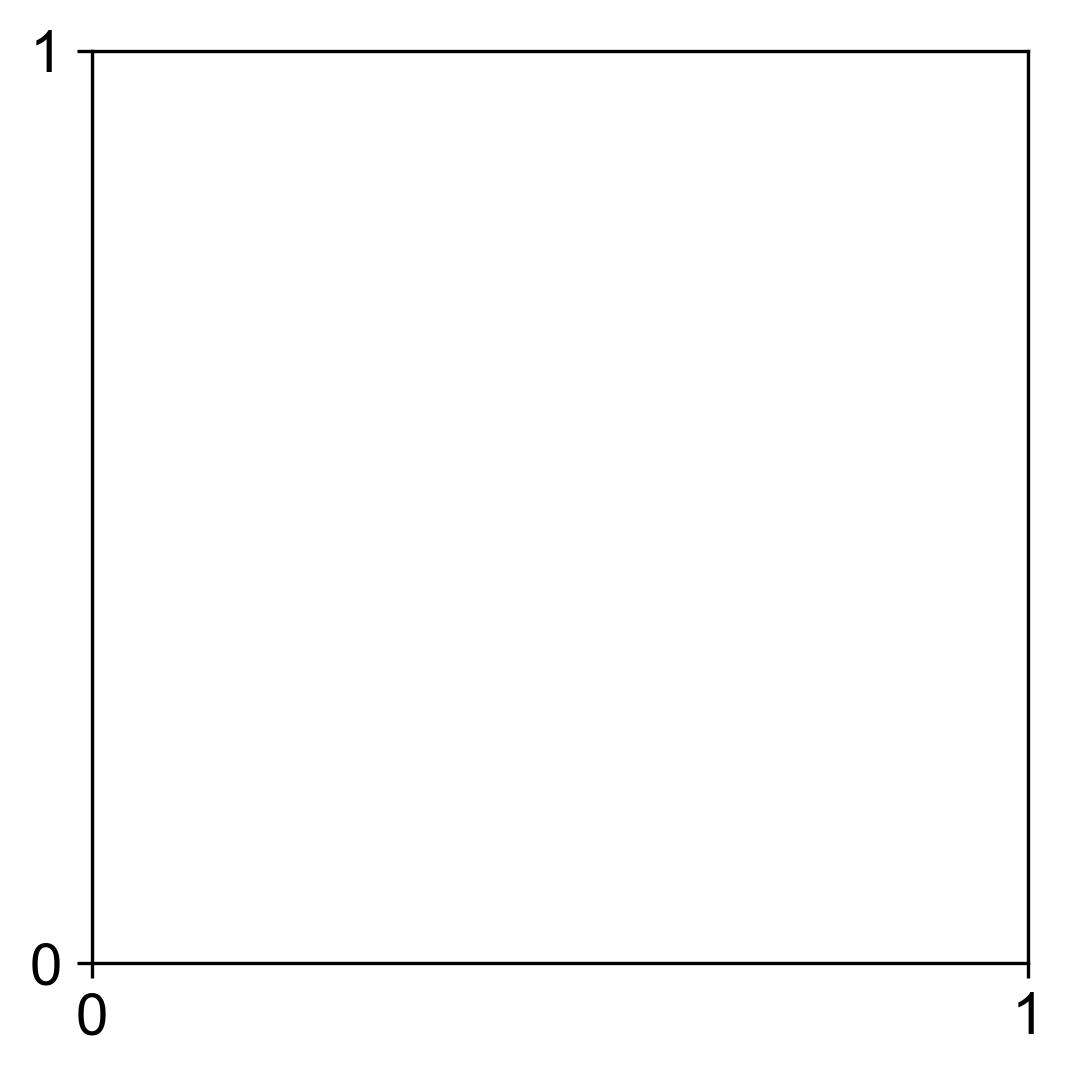

In [103]:
# Confusion matrix 
cnf_matrix = confusion_matrix(y_test, predicted_labels)

class_names=[0,1] # name  of classes
fig, ax = matplotlib.pyplot.subplots()
tick_marks = numpy.arange(len(class_names))
matplotlib.pyplot.xticks(tick_marks, class_names)
matplotlib.pyplot.yticks(tick_marks, class_names)

<Axes: >

Text(0.5, 1.1, 'Confusion matrix')

Text(57.083333333333336, 0.5, 'Actual label')

Text(0.5, 39.08333333333335, 'Predicted label')

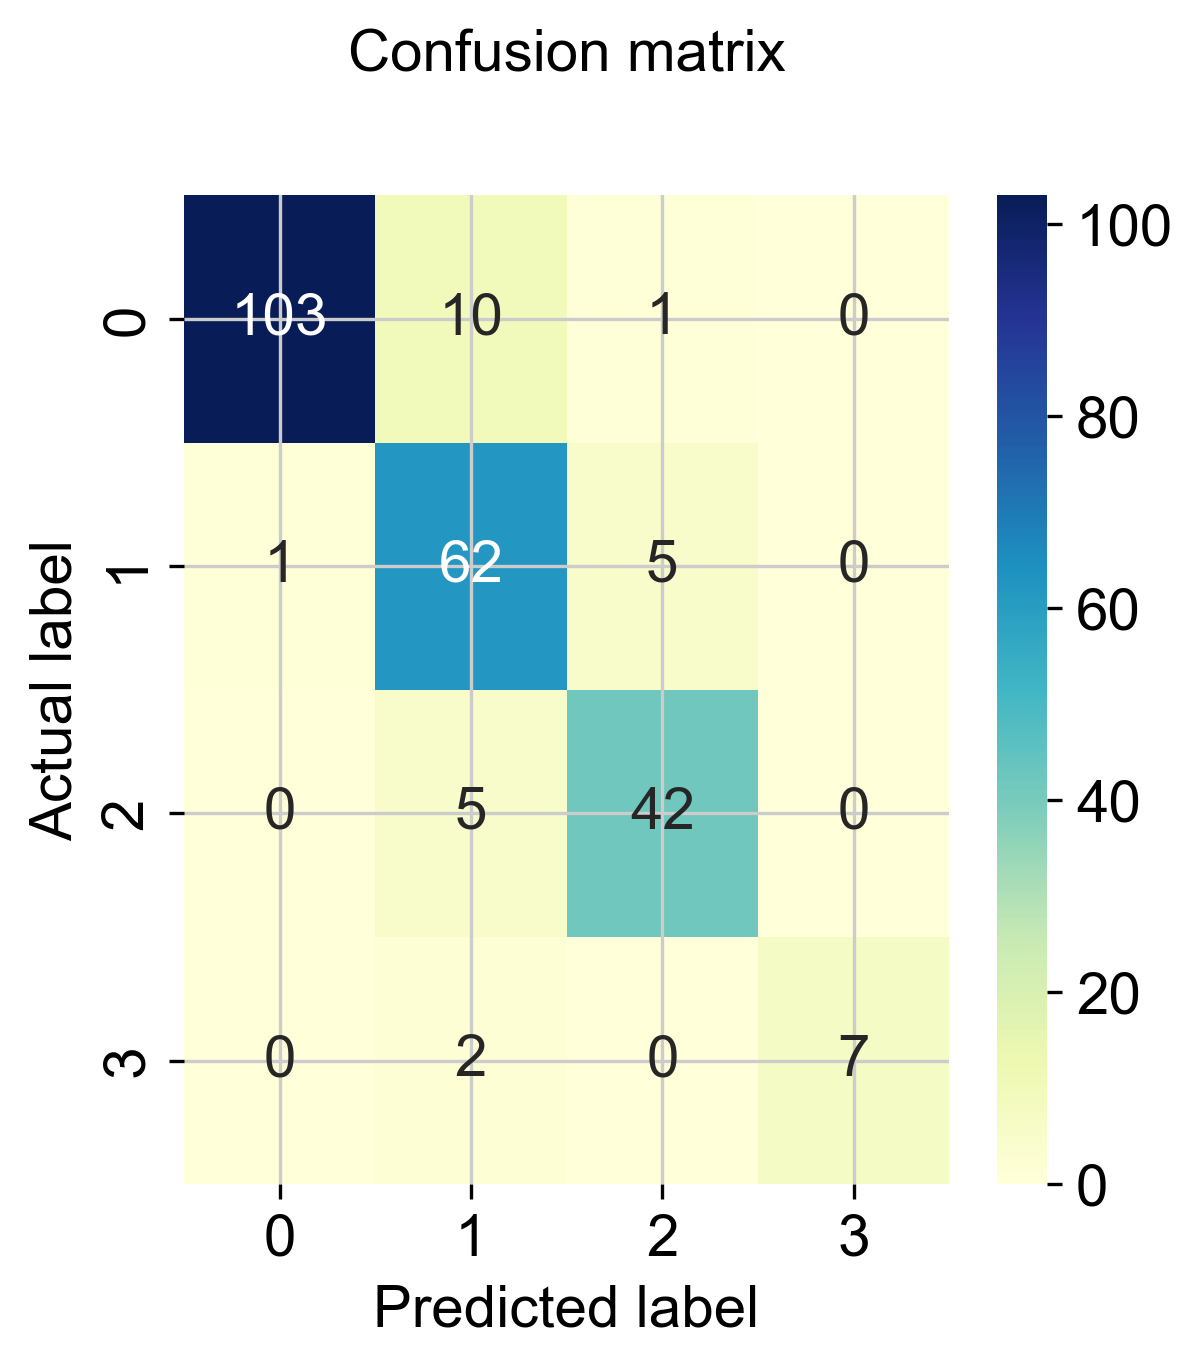

In [104]:
# create heatmap
seaborn.heatmap(pandas.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.title('Confusion matrix', y=1.1)
matplotlib.pyplot.ylabel('Actual label')
matplotlib.pyplot.xlabel('Predicted label')

In [105]:
# Transfer labels #
###################

grid.best_estimator_.feature_names = hvgs_X_train

def process_and_subset_data(adata, genes):
    # save the log transformed counts as raw 
    adata.raw = adata.copy()
    # Per cell normalization
    sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
    # Log transformation 
    sc.pp.log1p(adata)
    # Subset data
    adata = adata[:, list(genes)]
    # Scale
    sc.pp.scale(adata, max_value=10)
    return adata

def make_single_predictions(adata, classifier): 
    #if scipy.sparse.issparse(adata.X):
        #adata.X = adata.X.toarray()
    adata_X = numpy.array(adata.X)
    print(type(adata_X), adata_X.shape)
    adata_preds = classifier.predict(adata_X)
    adata.obs['classifier'] = adata_preds
    print(adata.obs.classifier.value_counts(dropna = False))
    
def make_correspondence(classifier):
    corr = {}
    for i in range(0,len(classifier.classes_)):
            corr[i] = classifier.classes_[i]
    return corr

def make_probability_predictions(adata, classifier):
    adata_X = numpy.array(adata.X)
    print(type(adata_X), adata_X.shape)
    proba_preds = classifier.predict_proba(adata_X)
    df_probs = pd.DataFrame(numpy.column_stack(list(zip(*proba_preds))))
    corr = make_correspondence(classifier)
    for index in df_probs.columns.values:
        celltype = corr[index]
        adata.obs['prob_'+celltype] = df_probs[index].to_list()

In [106]:
adata_human2 = process_and_subset_data(adata_human2, grid.best_estimator_.feature_names)
make_single_predictions(adata_human2, grid.best_estimator_)
make_probability_predictions(adata_human2, grid.best_estimator_)

to_save = ['classifier']
for i in adata_human2.obs.columns:
    if i.startswith('prob_'):
        to_save.append(i)

print('Saving the following obs: {}'.format(to_save))

normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added
    'n_counts', counts per cell before normalization (adata.obs)
<class 'numpy.ndarray'> (133, 2500)
classifier
Type IA    70
Type IB    45
Type IC    18
Name: count, dtype: int64
<class 'numpy.ndarray'> (133, 2500)
Saving the following obs: ['classifier', 'prob_Type IA', 'prob_Type IB', 'prob_Type IC', 'prob_Type II']


C:\Users\Dell\AppData\Local\Temp\ipykernel_14884\3327015638.py:10: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
G:\Miniconda3\envs\omicverse\lib\site-packages\scanpy\preprocessing\_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(
G:\Miniconda3\envs\omicverse\lib\site-packages\scanpy\preprocessing\_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
G:\Miniconda3\envs\omicverse\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [107]:
# Save transferred labels #
adata_human2.obs[to_save].to_csv(data_dir+'figures/figure4_S6/transferred_labels_svm_sgn_2500hvgs_revision2.csv')#CHANGE OHC IHC,RESPECTIVELY
#this csv formated-result then is as input as box-plot visualization in graphpad.

<Figure size 1800x1500 with 0 Axes>

<Figure size 2100x1500 with 0 Axes>

C:\Users\Dell\AppData\Local\Temp\ipykernel_14884\2088563897.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_probs = prob_data_with_true.groupby('true_celltype').mean()


<Axes: ylabel='true_celltype'>

Text(0.5, 1.0, 'Average Prediction Probabilities by True Cell Type')

Text(0.5, 174.08333333333334, 'Predicted Cell Types')

Text(327.0833333333333, 0.5, 'True Cell Types')

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0.5, 0, 'prob_Type IA'),
  Text(1.5, 0, 'prob_Type IB'),
  Text(2.5, 0, 'prob_Type IC'),
  Text(3.5, 0, 'prob_Type II')])

(array([0.5, 1.5, 2.5]),
 [Text(0, 0.5, 'NEFH+/RUNX1+/LYPD1+_mature_sgn'),
  Text(0, 1.5, 'NEFH+_mature_sgnn'),
  Text(0, 2.5, 'RUNX1+/LYPD1+_mature_sg')])

<Figure size 1800x1500 with 0 Axes>

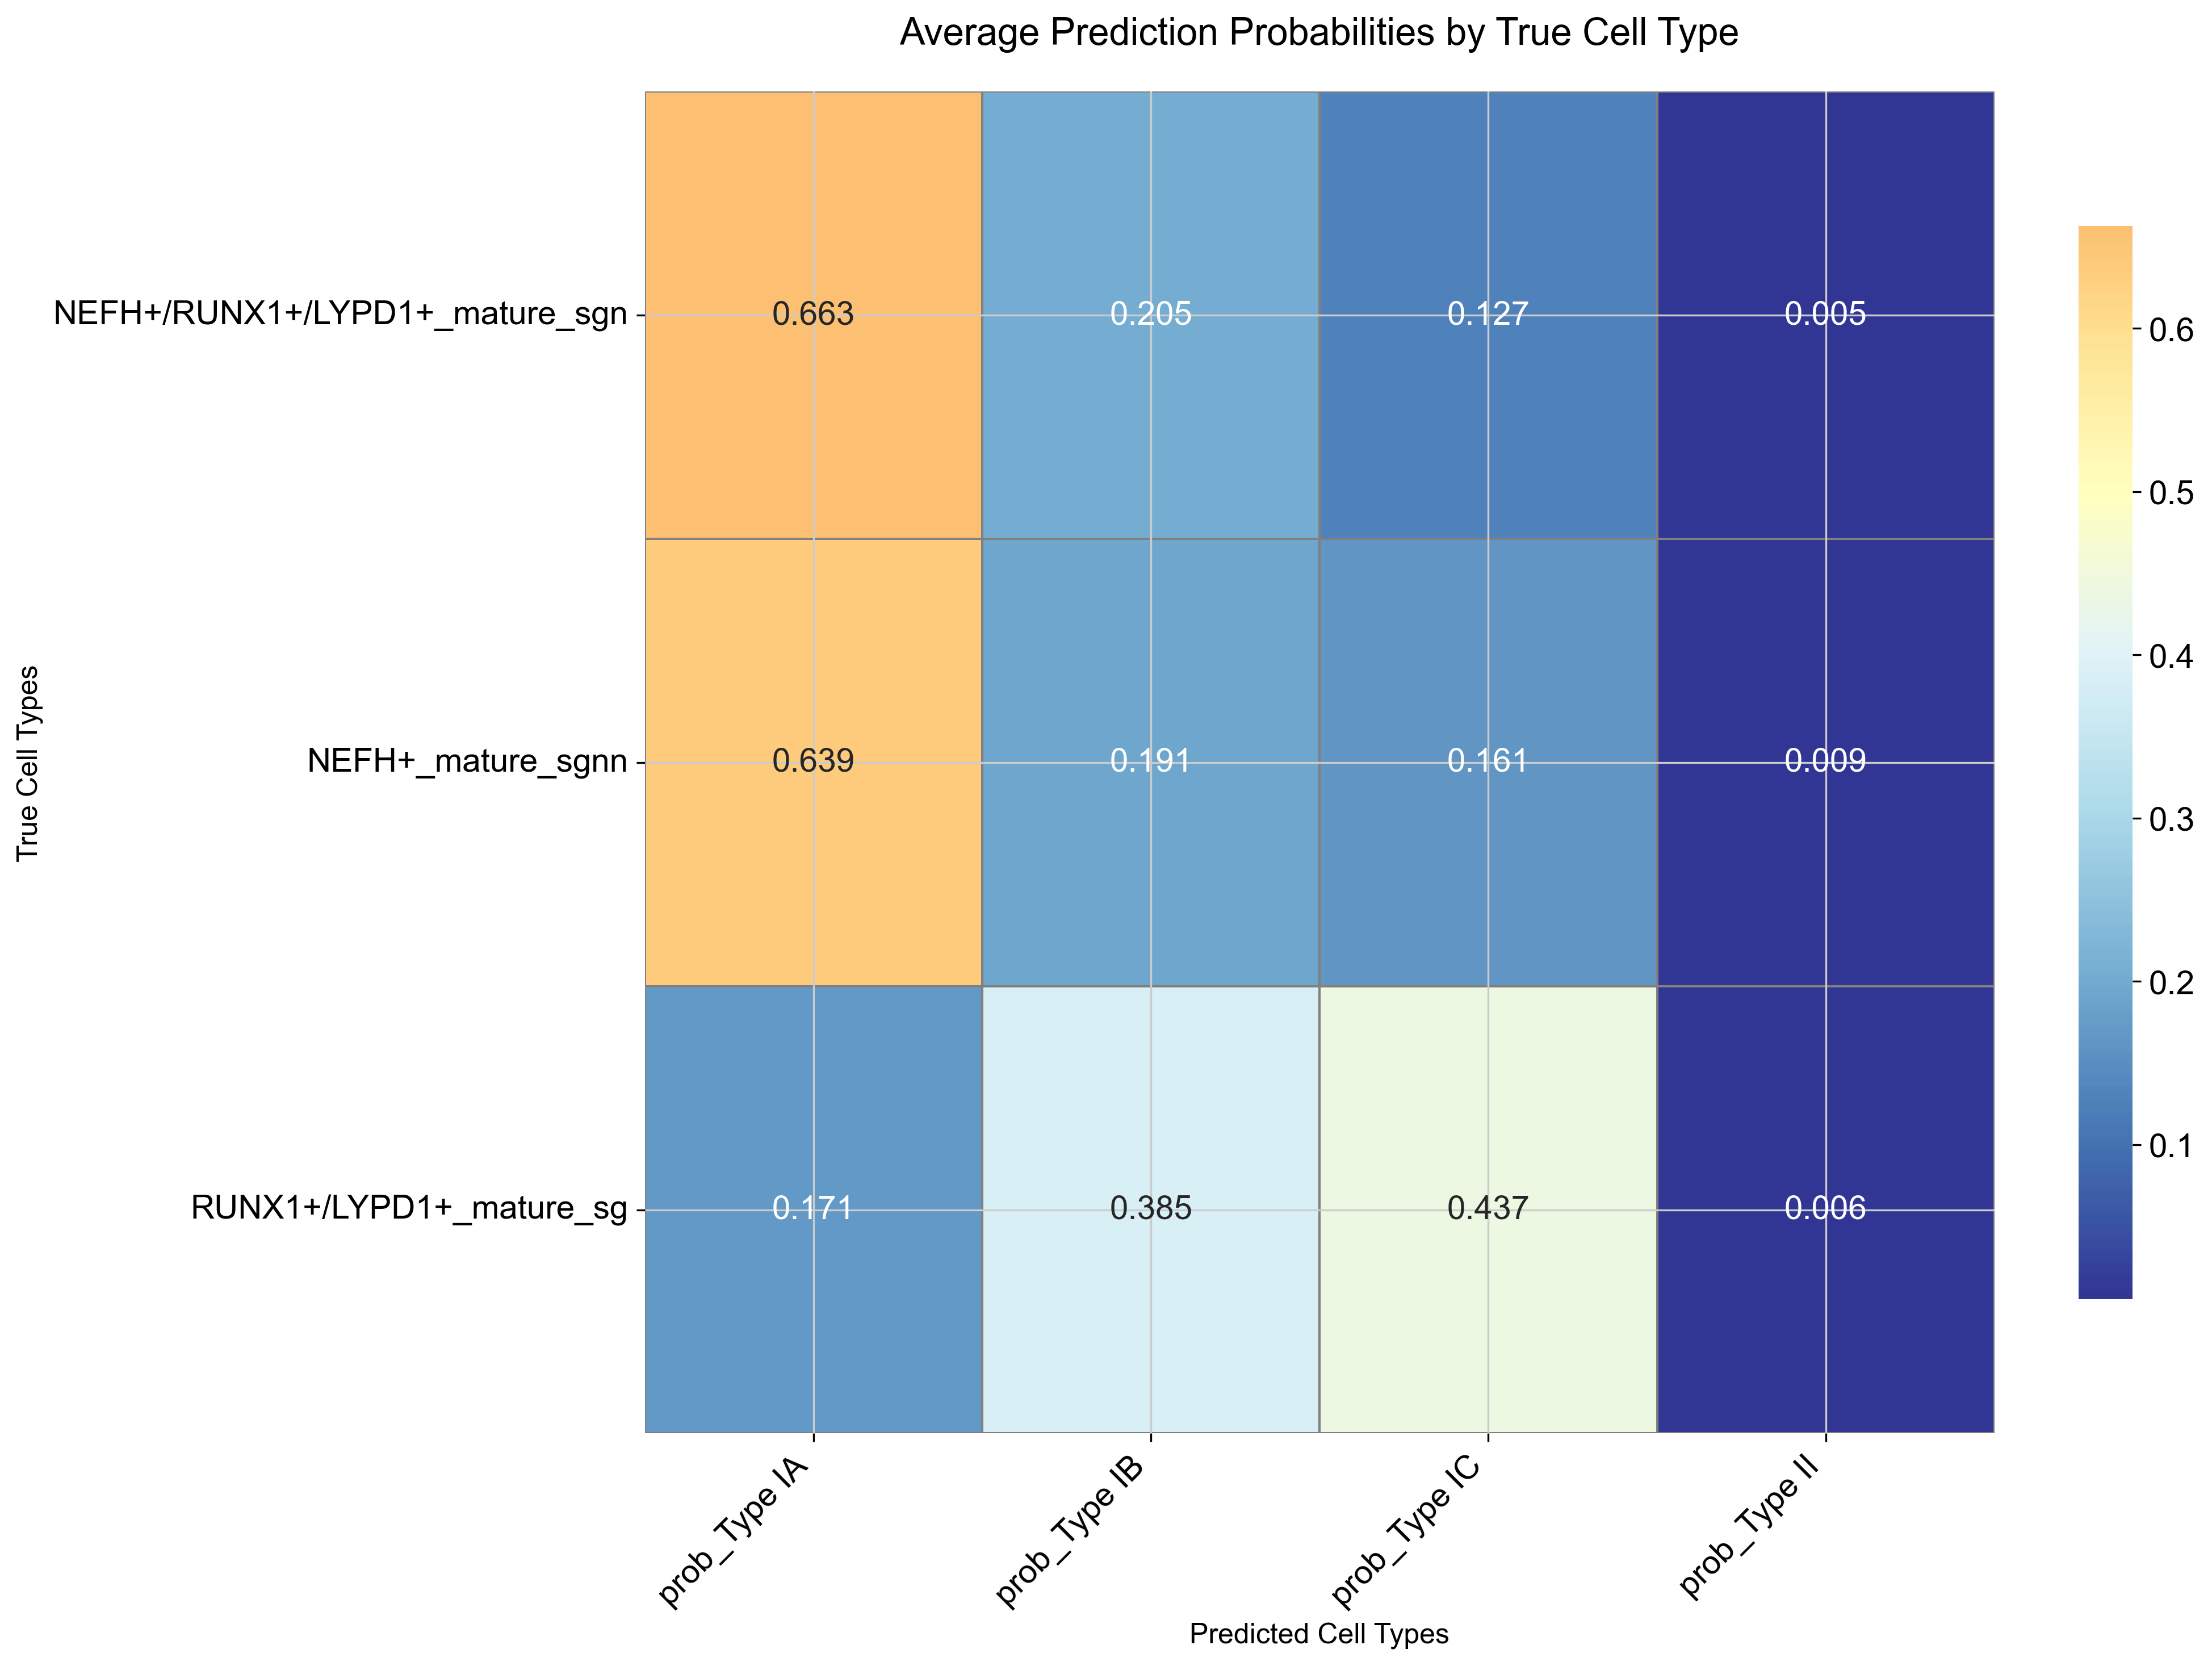

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import scanpy as sc


ml_results = pd.read_csv('transferred_labels_svm_sgn_1200hvgs_revision2.csv', index_col=0)


sc_data = adata_positive_final_sgn_hm_v2


true_labels = sc_data.obs['cell_type_final']


common_cells = ml_results.index.intersection(true_labels.index)


if len(common_cells) == 0:
   
    print("TOP 5 barcode:", ml_results.index[:5].tolist())
    print("TOP 5 barcode:", true_labels.index[:5].tolist())
else:
    
    ml_labels_common = ml_results.loc[common_cells, 'classifier']
    true_labels_common = true_labels.loc[common_cells]

    
    cm = confusion_matrix(true_labels_common, ml_labels_common)

    
    all_celltypes = sorted(set(true_labels_common.unique()) | set(ml_labels_common.unique()))

    
    cm_full = confusion_matrix(true_labels_common, ml_labels_common, labels=all_celltypes)

    
    cm_df = pd.DataFrame(cm_full, 
                        index=[f"True_{ct}" for ct in all_celltypes],
                        columns=[f"Pred_{ct}" for ct in all_celltypes])

   
    plt.figure(figsize=(12, 10))

    
   
    plt.figure(figsize=(14, 10))

   
    prob_cols = [col for col in ml_results.columns if col.startswith('prob_')]
    prob_data = ml_results.loc[common_cells, prob_cols]

  
    prob_data_with_true = prob_data.copy()
    prob_data_with_true['true_celltype'] = true_labels_common

    
    avg_probs = prob_data_with_true.groupby('true_celltype').mean()

   
    sns.heatmap(avg_probs, 
                annot=True, 
                fmt='.3f',
                cmap='RdYlBu_r',
                center=0.5,
                cbar_kws={'shrink': 0.8},
                square=False,
                linewidths=0.5,
                linecolor='gray')

    plt.title('Average Prediction Probabilities by True Cell Type', 
              fontsize=16, pad=20)
    plt.xlabel('Predicted Cell Types', fontsize=12)
    plt.ylabel('True Cell Types', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.savefig('average_prediction_probabilities.pdf', dpi=300, bbox_inches='tight')
    plt.show()

   
    analysis_df = pd.DataFrame({
        'true_celltype': true_labels_common,
        'predicted_celltype': ml_labels_common
    })


    for ct in prob_cols:
        analysis_df[ct] = ml_results.loc[common_cells, ct]

    
    analysis_df['correct'] = analysis_df['true_celltype'] == analysis_df['predicted_celltype']

   
    analysis_df.to_csv('celltype_classification_analysis.csv')

    

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


<Figure size 1200x900 with 0 Axes>

[Text(0.5, 0, 'Type IA'),
 Text(1.5, 0, 'Type IB'),
 Text(2.5, 0, 'Type IC'),
 Text(3.5, 0, 'Type II')]

[Text(0, 0.5, 'NEFH+/RUNX1+/LYPD1+_mature_sgn'),
 Text(0, 1.5, 'NEFH+_mature_sgnn'),
 Text(0, 2.5, 'RUNX1+/LYPD1+_mature_sg')]

Text(0.5, 1.0, 'Jaccard Similarity Between Cell Types')

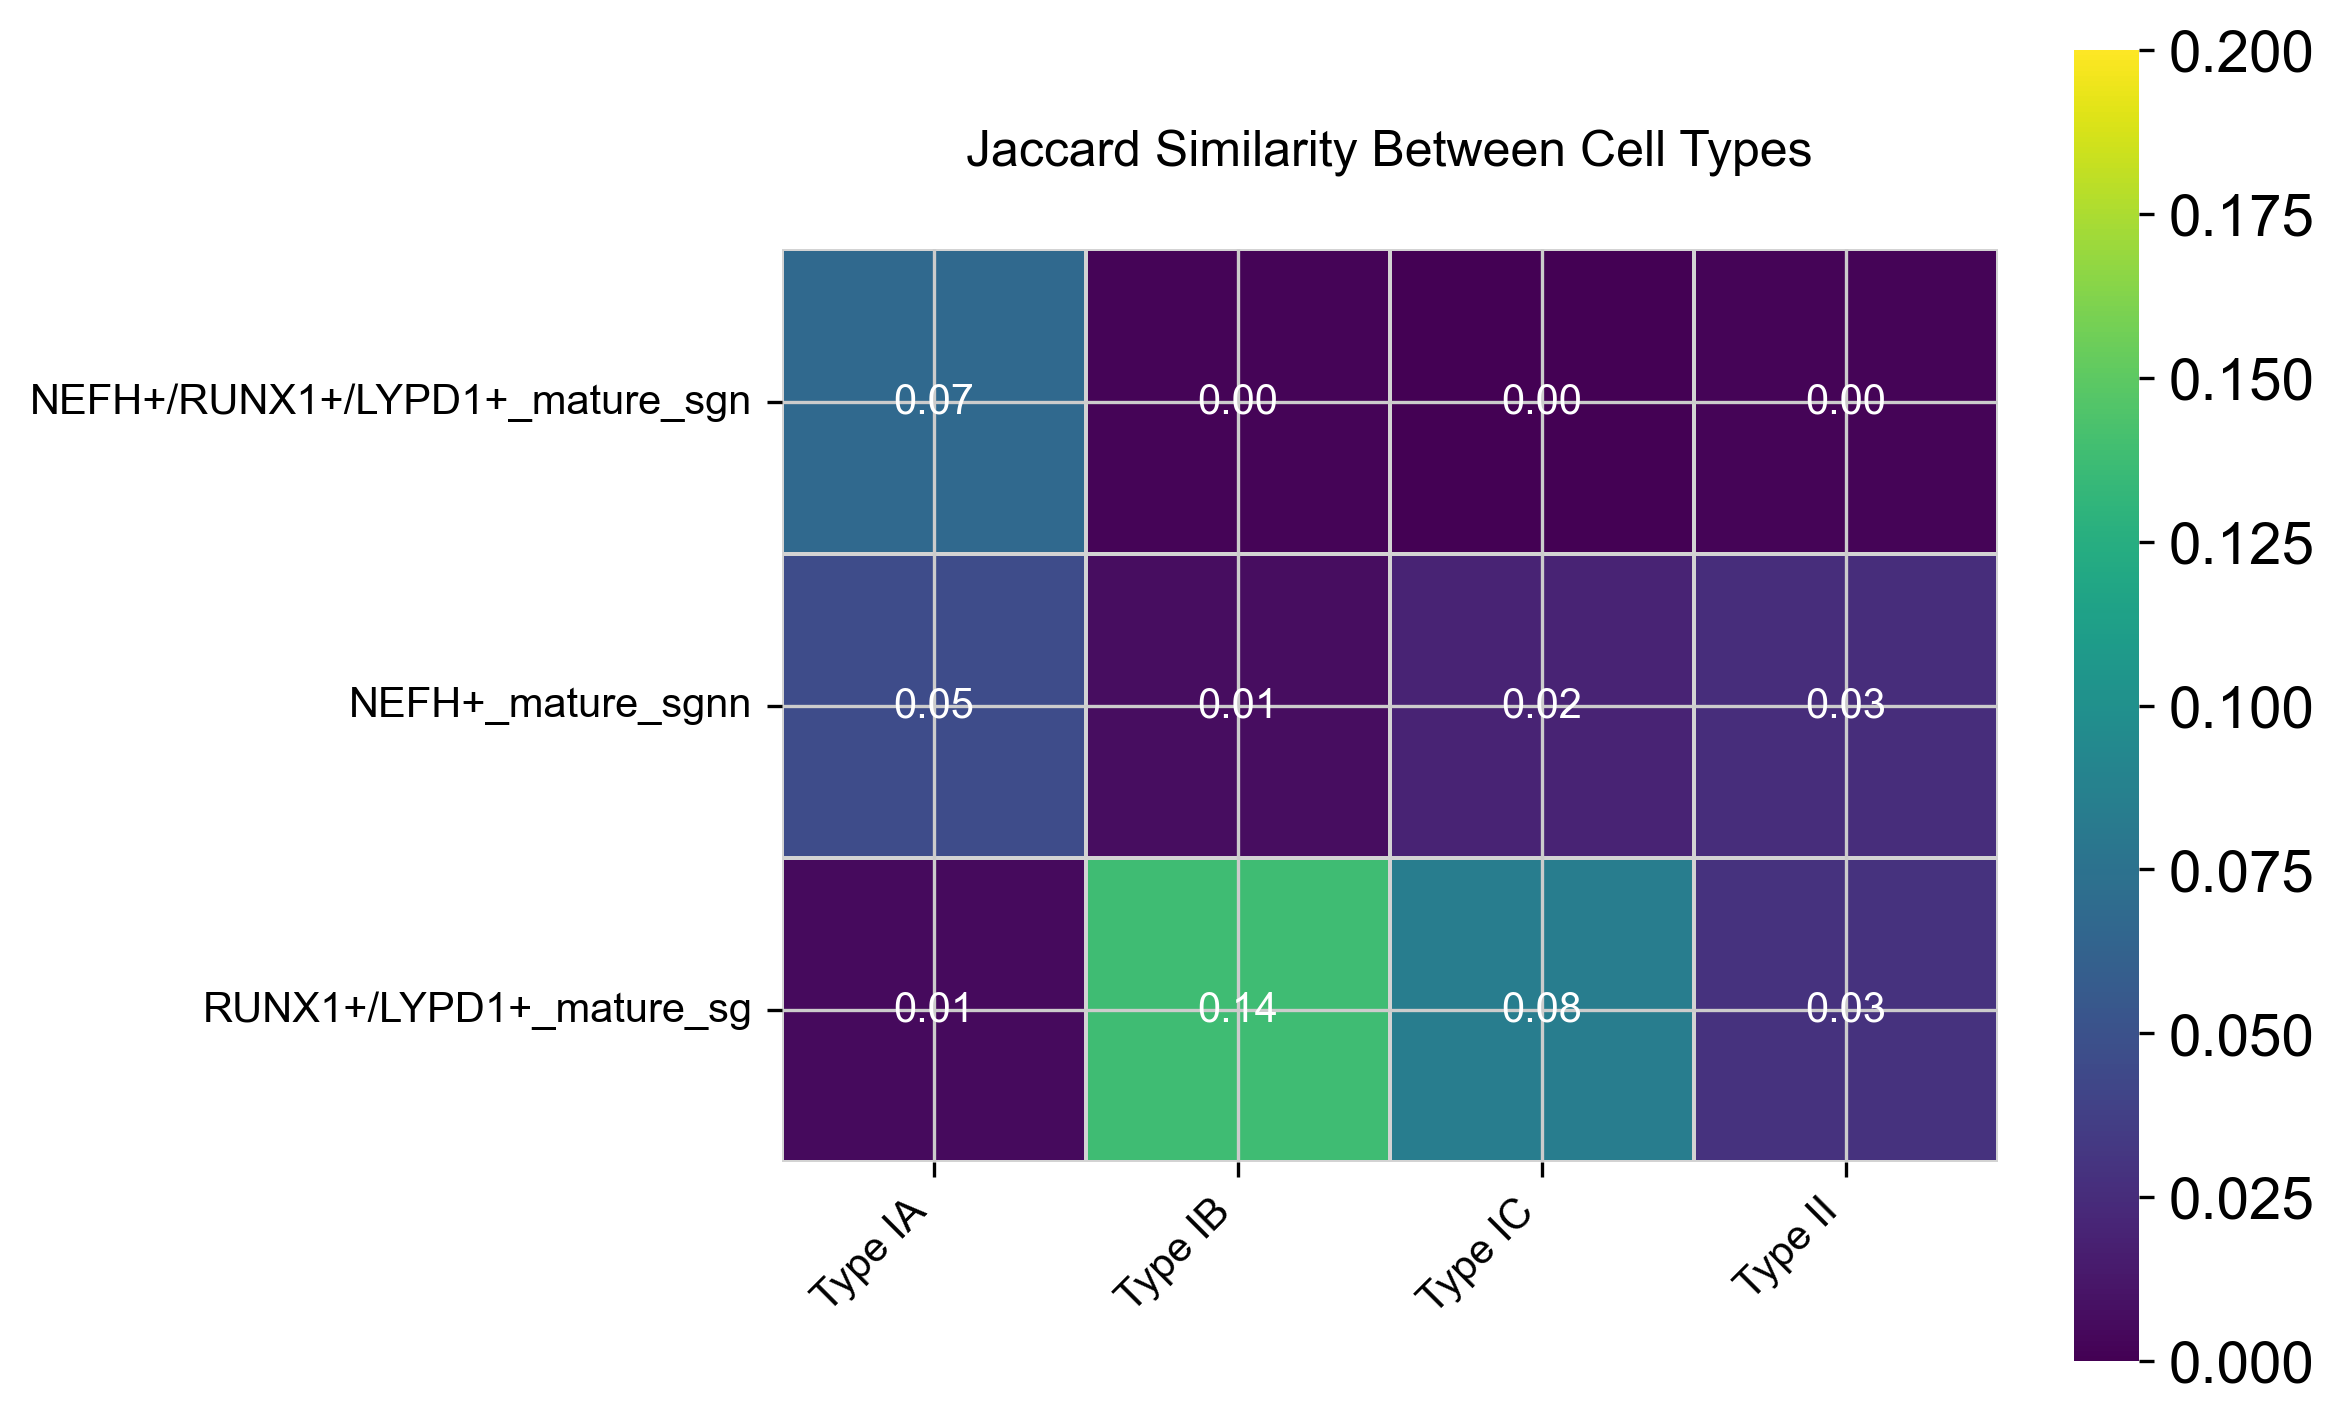

In [115]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

human_sgn = adata_to
mouse_sgn = adata_from

# Set the cell type identities
human_sgn.obs['celltype'] = human_sgn.obs['celltype'].astype('category')
mouse_sgn.obs['celltype'] = mouse_sgn.obs['celltype'].astype('category')

# Find markers for each cell type
sc.tl.rank_genes_groups(human_sgn, groupby='celltype', method='t-test_overestim_var', corr_method='benjamini-hochberg', use_raw=False)
sc.tl.rank_genes_groups(mouse_sgn, groupby='celltype', method='t-test_overestim_var', corr_method='benjamini-hochberg', use_raw=False)

# Get DEGs for each cluster with proper boolean conditions
deg_hu_sgn = sc.get.rank_genes_groups_df(human_sgn, group=None)
deg_hu_sgn = deg_hu_sgn[(deg_hu_sgn['logfoldchanges'] > 0.5) & (deg_hu_sgn['pvals'] < 0.01)]

deg_mu_sgn = sc.get.rank_genes_groups_df(mouse_sgn, group=None)
deg_mu_sgn = deg_mu_sgn[(deg_mu_sgn['logfoldchanges'] > 0.5) & (deg_mu_sgn['pvals'] < 0.01)]

# Get unique clusters
cluster1 = deg_hu_sgn['group'].unique()
cluster2 = deg_mu_sgn['group'].unique()

# Calculate Jaccard similarity matrix
df_ja = pd.DataFrame(index=cluster1, columns=cluster2)

for i in cluster1:
    a = set(deg_hu_sgn[deg_hu_sgn['group'] == i]['names'])
    for j in cluster2:
        b = set(deg_mu_sgn[deg_mu_sgn['group'] == j]['names'])
        intersection = len(a.intersection(b))
        union = len(a.union(b))
        jaccard = intersection / union if union != 0 else 0
        df_ja.loc[i, j] = jaccard

# Convert to numeric
df_ja = df_ja.astype(float)

# Plot heatmap
plt.figure(figsize=(8, 6))  


ax = sns.heatmap(
    df_ja,
    cmap='viridis',  #sns.diverging_palette(240, 10, n=100), 
    vmin=0,
    vmax=0.2,
    linewidths=0.5,
    linecolor='lightgray',
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10},  
    cbar_kws={"shrink": 0.8}, 
    square=True  
)


ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)


plt.title("Jaccard Similarity Between Cell Types", pad=20, fontsize=12)

# 调整布局
plt.tight_layout()


plt.savefig(
    'human_sgn_Jaccard_Similarity_Between_Cell_Types_REVISION2.pdf',
    dpi=300,  # 提高分辨率
    bbox_inches='tight'
)

plt.show()